# AICE Professioanl 대비 - 텍스트 처리(NLP) 실습
[Korean Hate Speech Dataset]
- 소개: 고려대학교 NLP 연구실에서 공개한 혐오 발언 탐지 데이터셋으로, 온라인 댓글과 그에 대한 혐오 표현 여부를 포함하고 있습니다.
- 링크: Korean Hate Speech Dataset
- 특징: 온라인 커뮤니티의 댓글을 기반으로 하며, 혐오 발언, 욕설, 일반 발언으로 분류되어 있습니다.

## NLP 순서
- 텍스트 데이터 전처리
- 한글 형태소 분석(Okt, Mecab 등)
- Tokenizer(Word Dictionary 생성)
- Texts to Sequences
- Embedding(단어 밀집벡터 표현)
- LSTM 모델링


## 모델링 순서

**1. 데이터 로드 및 공통 전처리**
- train_data, test_data Load
- Preprocess -> 라벨인코딩, 결측치 제거 및 텍스트 정제(한글 외 문자 제거)

**2. 머신러닝**
- 2.1 머신러닝 모델링
- 2.2 머신러닝 모델 평가 및 예측

**3. 딥러닝 모델링**
- 3.1 전처리: 1)형태소 분석(Mecab), 2)단어 인덱스화(Tokenizer), 3)Padding 처리
- 3.2 딥러닝 모델링
- 3.3 딥러닝 모델 평가 및 예측



# 1. 데이터 로드 및 전처리
## 데이터 로드
Korean Hate Speech Dataset을 GitHub에서 다운로드하고 로드합니다.

In [1]:
!git clone https://github.com/kocohub/korean-hate-speech.git

fatal: 대상 경로가('korean-hate-speech') 이미 있고 빈 디렉터리가 아닙니다.


In [2]:
# 필요한 라이브러리 임포트
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import urllib.request
from tqdm import tqdm
import tensorflow as tf


# 데이터 로드
train_data = pd.read_csv('korean-hate-speech/labeled/train.tsv', sep='\t')
test_data = pd.read_csv('korean-hate-speech/labeled/dev.tsv', sep='\t')


## 데이터 확인
데이터의 구조와 결측값 여부를 확인합니다.

In [3]:
# 데이터 확인
print(train_data.head())
print(train_data.isnull().sum())


                                            comments  contain_gender_bias  \
0  (현재 호텔주인 심정) 아18 난 마른하늘에 날벼락맞고 호텔망하게생겼는데 누군 계속...                False   
1  ....한국적인 미인의 대표적인 분...너무나 곱고아름다운모습...그모습뒤의 슬픔을...                False   
2  ...못된 넘들...남의 고통을 즐겼던 넘들..이젠 마땅한 처벌을 받아야지..,그래...                False   
3                 1,2화 어설펐는데 3,4화 지나서부터는 갈수록 너무 재밌던데                False   
4  1. 사람 얼굴 손톱으로 긁은것은 인격살해이고2. 동영상이 몰카냐? 메걸리안들 생각...                 True   

     bias  hate  
0  others  hate  
1    none  none  
2    none  hate  
3    none  none  
4  gender  hate  
comments               0
contain_gender_bias    0
bias                   0
hate                   0
dtype: int64


In [4]:
train_data.columns

Index(['comments', 'contain_gender_bias', 'bias', 'hate'], dtype='str')

In [5]:
# 데이터 확인
print(test_data.head())
print(test_data.isnull().sum())


                                            comments  contain_gender_bias  \
0                        송중기 시대극은 믿고본다. 첫회 신선하고 좋았다.                False   
1                                            지현우 나쁜놈                False   
2         알바쓰고많이만들면되지 돈욕심없으면골목식당왜나온겨 기댕기게나하고 산에가서팔어라                False   
3                                   설마 ㅈ 현정 작가 아니지??                 True   
4  이미자씨 송혜교씨 돈이 그리 많으면 탈세말고 그돈으로 평소에 불우이웃에게 기부도 좀...                False   

     bias       hate  
0    none       none  
1    none  offensive  
2    none       hate  
3  gender       hate  
4    none  offensive  
comments               0
contain_gender_bias    0
bias                   0
hate                   0
dtype: int64


In [6]:
test_data

,comments,contain_gender_bias,bias,hate
0,송중기 시대극은 믿고본다. 첫회 신선하고 좋았다.,False,none,none
1,지현우 나쁜놈,False,none,offensive
2,알바쓰고많이만들면되지 돈욕심없으면골목식당왜나온겨 기댕기게나하고 산에가서팔어라,False,none,hate
3,설마 ㅈ 현정 작가 아니지??,True,gender,hate
4,이미자씨 송혜교씨 돈이 그리 많으면 탈세말고 그돈으로 평소에 불우이웃에게 기부도 좀...,False,none,offensive
...,...,...,...,...
466,지현우 범죄 저지르지 않았나요?,False,none,offensive
467,여자인생 망칠 일 있나 ㅋㅋ,True,gender,hate
468,근데 전라도에서 사고가 났는데 굳이 서울까지 와서 병원에 가느 이유는?,False,others,offensive
469,"할매젖x, 뱃살x, 몸매 s라인, 유륜은 적당해야됨(너무크거나 너무 작아도 x), ...",True,gender,hate


## 라벨 변경
라벨을 숫자로 인코딩합니다.

- hate: 혐오 발언 (2)
- offensive: 욕설 (1)
- none: 일반 발언 (0)

In [7]:
# 레이블 인코딩
label_mapping = {'none': 0, 'offensive': 1, 'hate': 2}
train_data['label'] = train_data['hate'].map(label_mapping)
test_data['label'] = test_data['hate'].map(label_mapping)


In [8]:
train_data

,comments,contain_gender_bias,bias,hate,label
0,(현재 호텔주인 심정) 아18 난 마른하늘에 날벼락맞고 호텔망하게생겼는데 누군 계속...,False,others,hate,2
1,....한국적인 미인의 대표적인 분...너무나 곱고아름다운모습...그모습뒤의 슬픔을...,False,none,none,0
2,"...못된 넘들...남의 고통을 즐겼던 넘들..이젠 마땅한 처벌을 받아야지..,그래...",False,none,hate,2
3,"1,2화 어설펐는데 3,4화 지나서부터는 갈수록 너무 재밌던데",False,none,none,0
4,1. 사람 얼굴 손톱으로 긁은것은 인격살해이고2. 동영상이 몰카냐? 메걸리안들 생각...,True,gender,hate,2
...,...,...,...,...,...
7891,힘내세요~ 응원합니다!!,False,none,none,0
7892,힘내세요~~삼가 고인의 명복을 빕니다..,False,none,none,0
7893,힘내세용 ^^ 항상 응원합니닷 ^^ !,False,none,none,0
7894,힘내소...연기로 답해요.나도 53살 인데 이런일 저런일 다 있더라구요.인격을 믿습...,False,none,none,0


## 텍스트 정제
한글 외의 문자들을 삭제하여 텍스트를 정제합니다.

In [9]:
# 한글 외 문자 제거
train_data['comments'] = train_data['comments'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True)
test_data['comments'] = test_data['comments'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True)


# 2. 머신러닝
## 2.1 머신러닝 모델링

머신러닝 모델을 사용할 때:
TF-IDF와 같은 벡터화 기법을 사용하여 고정 길이의 입력 데이터를 생성합니다.

단어의 순서나 문맥 정보가 크게 중요하지 않을 때 효과적입니다.

### TF-IDF 벡터화
텍스트 데이터를 TF-IDF 벡터로 변환합니다.

In [10]:
# TF-IDF 벡터화
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF 벡터라이저 생성
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(train_data['comments'])
X_test_tfidf = vectorizer.transform(test_data['comments'])

# 레이블 추출
y_train = np.array(train_data['label'])
y_test = np.array(test_data['label'])


## 머신러닝 모델 학습
랜덤 포레스트 분류기를 사용하여 학습합니다.

In [11]:
# 랜덤 포레스트 모델 학습
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train_tfidf, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 2.2 머신러닝 모델 평가 및 예측
### 모델 평가
테스트 데이터를 사용하여 머신러닝 모델의 성능을 평가합니다.

In [12]:
# 모델 평가
from sklearn.metrics import accuracy_score

y_pred_ml = rf_model.predict(X_test_tfidf)
accuracy_ml = accuracy_score(y_test, y_pred_ml)
print('머신러닝 모델 테스트 정확도: {:.4f}'.format(accuracy_ml))


머신러닝 모델 테스트 정확도: 0.4395


예측 함수 정의
새로운 문장에 대한 예측을 수행하는 함수를 정의합니다.

In [13]:
# 예측 함수 정의
def ml_sentiment_predict(new_sentence):
    new_sentence = re.sub("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", new_sentence)
    vector = vectorizer.transform([new_sentence])
    result = rf_model.predict(vector)
    labels = {0: '일반 발언', 1: '욕설', 2: '혐오 발언'}
    print(f"'{labels[result[0]]}'로 분류되었습니다.")


**예시 문장 예측**

In [14]:
# 예시 문장 예측
ml_sentiment_predict('이 사람 정말 싫어요.')
ml_sentiment_predict('안녕하세요, 좋은 하루입니다.')


'일반 발언'로 분류되었습니다.
'일반 발언'로 분류되었습니다.




---



---



# 3. 딥러닝

## 3.1 딥러닝 전처리


## 형태소 분석 및 토큰화
Mecab 형태소 분석기를 사용하여 텍스트를 토큰화합니다.

Mecab 설치
Colab에서 Mecab을 사용하기 위해 설치합니다.

In [17]:
# Colab/로컬 공통 Mecab 설치
import os
import sys
import subprocess

if 'google.colab' in sys.modules:
    repo_dir = '/content/Mecab-ko-for-Google-Colab'
    %cd /content

    if not os.path.isdir(repo_dir):
        !git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
    else:
        print('이미 저장소가 있어 clone을 건너뜁니다.')

    %cd /content/Mecab-ko-for-Google-Colab

    candidate_scripts = [
        'install_mecab-ko_on_colab_light_220429.sh',
        'install_mecab-ko_on_colab_light.sh',
        'install_mecab-ko_on_colab190912.sh',
        'install_mecab-ko_on_colab.sh',
    ]

    install_script = next((s for s in candidate_scripts if os.path.exists(s)), None)
    if install_script is None:
        !ls -la
        raise FileNotFoundError('Mecab 설치 스크립트를 찾지 못했습니다.')

    print(f'실행 스크립트: {install_script}')
    !bash {install_script}
    print('설치 완료. 런타임 재시작 후 다음 셀부터 실행하세요.')
else:
    print('로컬 환경: python-mecab-ko 기반 Mecab 설치를 진행합니다.')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'python-mecab-ko', 'python-mecab-ko-dic', 'konlpy'])
    print('설치 완료: python-mecab-ko, python-mecab-ko-dic, konlpy')

로컬 환경: python-mecab-ko 기반 Mecab 설치를 진행합니다.
설치 완료: python-mecab-ko, python-mecab-ko-dic, konlpy



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 형태소 분석기 임포트 및 토큰화

In [32]:
# 형태소 분석기 임포트 (환경별 Mecab 자동 선택)
tokenizer_name = None

class _TokenizerProxy:
    def __init__(self, morphs_fn):
        self._morphs_fn = morphs_fn

    def morphs(self, doc):
        return self._morphs_fn(doc)

try:
    from konlpy.tag import Mecab as KoNLPyMecab
    _mecab = KoNLPyMecab()
    tokenizer_name = 'KoNLPy Mecab'

    def _morphs(doc):
        return _mecab.morphs(str(doc))

    mecab = _mecab

except Exception:
    try:
        import mecab_ko_dic
        if not hasattr(mecab_ko_dic, 'DICDIR'):
            mecab_ko_dic.DICDIR = mecab_ko_dic.dictionary_path

        from mecab_ko import Tagger
        _tagger = Tagger(f'-r /dev/null -d "{mecab_ko_dic.dictionary_path}"')
        tokenizer_name = 'python-mecab-ko Tagger'

        def _morphs(doc):
            parsed = _tagger.parse(str(doc))
            return [line.split('\t')[0] for line in parsed.splitlines() if line and line != 'EOS']

        mecab = _TokenizerProxy(_morphs)

    except Exception:
        from konlpy.tag import Okt
        _okt = Okt()
        tokenizer_name = 'Okt (fallback)'

        def _morphs(doc):
            return _okt.morphs(str(doc), stem=True)

        mecab = _TokenizerProxy(_morphs)

print(f'사용 토크나이저: {tokenizer_name}')

# 토큰화 적용
train_data['tokenized'] = train_data['comments'].apply(_morphs)
test_data['tokenized'] = test_data['comments'].apply(_morphs)


사용 토크나이저: python-mecab-ko Tagger


In [20]:
train_data

,comments,contain_gender_bias,bias,hate,label,tokenized
0,현재 호텔주인 심정 아 난 마른하늘에 날벼락맞고 호텔망하게생겼는데 누군 계속 추모받네,False,others,hate,2,"[현재, 호텔, 주인, 심정, 아, 난, 마른, 하늘, 에, 날벼락, 맞, 고, 호..."
1,한국적인 미인의 대표적인 분너무나 곱고아름다운모습그모습뒤의 슬픔을 미처 알지못했네요ㅠ,False,none,none,0,"[한국, 적, 인, 미인, 의, 대표, 적, 인, 분, 너무나, 곱, 고, 아름다운..."
2,못된 넘들남의 고통을 즐겼던 넘들이젠 마땅한 처벌을 받아야지그래야 공정한 사회지심은...,False,none,hate,2,"[못, 된, 넘, 들, 남, 의, 고통, 을, 즐겼, 던, 넘, 들, 이젠, 마땅,..."
3,화 어설펐는데 화 지나서부터는 갈수록 너무 재밌던데,False,none,none,0,"[화, 어설펐, 는데, 화, 지나, 서, 부터, 는, 갈수록, 너무, 재밌, 던데]"
4,사람 얼굴 손톱으로 긁은것은 인격살해이고 동영상이 몰카냐 메걸리안들 생각이 없노,True,gender,hate,2,"[사람, 얼굴, 손톱, 으로, 긁, 은, 것, 은, 인격, 살해, 이, 고, 동영상..."
...,...,...,...,...,...,...
7891,힘내세요 응원합니다,False,none,none,0,"[힘내, 세요, 응, 원합니다]"
7892,힘내세요삼가 고인의 명복을 빕니다,False,none,none,0,"[힘내, 세요, 삼가, 고인, 의, 명복, 을, 빕, 니다]"
7893,힘내세용 항상 응원합니닷,False,none,none,0,"[힘내, 세용, 항상, 응, 원합, 니, 닷]"
7894,힘내소연기로 답해요나도 살 인데 이런일 저런일 다 있더라구요인격을 믿습니다홨팅,False,none,none,0,"[힘, 내소, 연기, 로, 답, 해요, 나, 도, 살, 인데, 이런, 일, 저런, ..."


## 단어 인덱스화
딥러닝 모델을 사용할 때:
Tokenizer와 임베딩 레이어를 사용하여 단어의 순서와 문맥을 고려합니다.

복잡한 패턴과 의미를 학습하고자 할 때 적합합니다.

각 단어를 고유한 정수로 인코딩합니다.

In [21]:
# 전체 단어 사전 구축
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_data['tokenized'])

# 텍스트를 시퀀스로 변환
X_train = tokenizer.texts_to_sequences(train_data['tokenized'])
X_test = tokenizer.texts_to_sequences(test_data['tokenized'])

# 레이블 추출
y_train = np.array(train_data['label'])
y_test = np.array(test_data['label'])


## 패딩 처리
입력 시퀀스의 길이를 동일하게 맞추기 위해 패딩을 적용합니다.

In [22]:
max(len(line) for line in X_train)

70

In [23]:
# 패딩 처리
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(len(line) for line in X_train)  # 최대 문장 길이 지정
X_train_padded = pad_sequences(X_train, maxlen=max_len)
X_test_padded = pad_sequences(X_test, maxlen=max_len)


## 3.2 딥러닝 모델링
###  모델 구성
임베딩 층과 LSTM 층을 활용하여 모델을 구성합니다.

In [24]:
from tensorflow.keras.layers import Dense, Flatten, Conv1D, MaxPool2D
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, SimpleRNN, GRU, Dropout, SpatialDropout1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# 토크나이저 단어 사전 크기를 모델 입력 차원으로 사용해야 인덱스 에러를 피할 수 있음
max_words = len(tokenizer.word_index) + 1
max_len = max(len(line) for line in X_train)       # 패딩 시퀀스의 최대 길이

embedding_dim = 128  # 임베딩 차원
lstm_units = 128     # LSTM 유닛 수

# 모델 구성
dl_model = Sequential()
dl_model.add(Embedding(input_dim=max_words, output_dim=embedding_dim))  # 단어 사전 크기, 임베딩 벡터 차원
dl_model.add(LSTM(lstm_units))  # LSTM 레이어
dl_model.add(Dense(3, activation='softmax'))  # 출력층

# 모델 컴파일
dl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 모델 학습
훈련 데이터를 사용하여 모델을 학습시킵니다.

In [25]:
# 조기종료 콜백함수 정의(EarlyStopping)
es = EarlyStopping(monitor='val_loss', patience=3, verbose=1)

# 체크포인트 저장(ModelCheckpoint)
checkpoint_path = 'tmp_checkpoint.weights.h5'
cp = ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', verbose=1, save_best_only=True, save_weights_only=True)

In [26]:
# 모델 학습
history = dl_model.fit(X_train_padded, y_train, epochs=5, batch_size=64, validation_split=0.2, verbose=1, callbacks=[es, cp])


Epoch 1/5
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4639 - loss: 1.0363
Epoch 1: val_loss improved from None to 0.91181, saving model to tmp_checkpoint.weights.h5

Epoch 1: finished saving model to tmp_checkpoint.weights.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4987 - loss: 0.9917 - val_accuracy: 0.5411 - val_loss: 0.9118
Epoch 2/5
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6595 - loss: 0.7432
Epoch 2: val_loss did not improve from 0.91181
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6715 - loss: 0.7200 - val_accuracy: 0.5797 - val_loss: 0.9246
Epoch 3/5
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8242 - loss: 0.4546
Epoch 3: val_loss did not improve from 0.91181
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8200 - loss: 0.4599 - val_accuracy: 0.5582 - val_loss: 1.0354
Epoch 4/5
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9034 - loss: 0.2708
Epoch 4: val_loss did not improve from 0.91181
99/99 ━━━━━━━━━━━━━━━━━

In [27]:
##모델 로드 웨이트
dl_model.load_weights(checkpoint_path)
##모델 저장
dl_model.save("NLP_mission_2.keras")

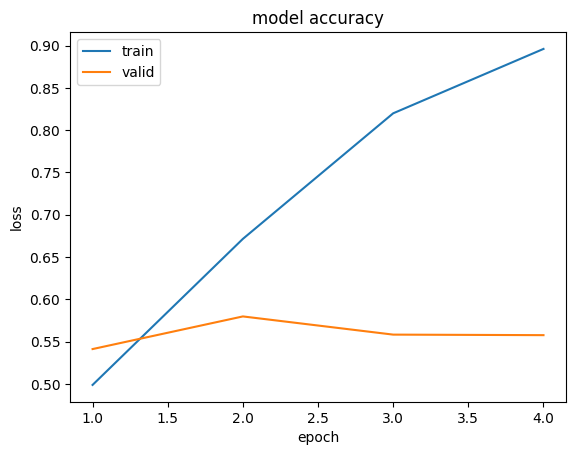

In [28]:
epochs = range(1, len(history.history['accuracy']) + 1)
plt.plot(epochs, history.history['accuracy'])
plt.plot(epochs, history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], )
plt.show()

## 3.3 딥러닝 모델 평가 및 예측
###모델 평가
테스트 데이터를 사용하여 딥러닝 모델의 성능을 평가합니다.

In [29]:
# 모델 평가
loss, accuracy = dl_model.evaluate(X_test_padded, y_test)
print('딥러닝 모델 테스트 정확도: {:.4f}'.format(accuracy))


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5117 - loss: 0.9416
딥러닝 모델 테스트 정확도: 0.5117


## 예측 함수 정의
새로운 문장에 대한 예측을 수행하는 함수를 정의합니다.

In [30]:
# 예측 함수 정의
def dl_sentiment_predict(new_sentence):
    new_sentence = re.sub("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", new_sentence)
    new_sentence = mecab.morphs(new_sentence)
    encoded = tokenizer.texts_to_sequences([new_sentence])
    pad_new = pad_sequences(encoded, maxlen=max_len)
    score = dl_model.predict(pad_new, verbose=0)
    labels = {0: '일반 발언', 1: '욕설', 2: '혐오 발언'}
    print(f"'{labels[np.argmax(score)]}'로 분류되었습니다.")


**예시 문장 예측**

In [33]:
# 예시 문장 예측
dl_sentiment_predict('이 사람 정말 싫어요.')
dl_sentiment_predict('안녕하세요, 좋은 하루입니다.')


'일반 발언'로 분류되었습니다.
'일반 발언'로 분류되었습니다.
